# Let's code swin in pytorch

I have some doubt on cyclic shifting of windows is it perfectly global attention? if you need more idea on what qsn is go to www.youtube.com/watch?v=kbUfsA3WP9U and in timestamp: 1:55:31.

still there are some patches who can't totally attend to everything with that clever cyclis algorith but multiple layers with reducing in spatial dimension kinda helps understand stuff.

I need some answers to which i am not fully convinced of like if we do the masking for the elements that are originally from different windows the plausible explanation is that pattches coming from far apart corner shdn't relate. but if we are masking that what is the use of rolling i mean it couldn't attend to newer patches it will just attend to the same old patches. I need some answer for this or am i lacking some knowledge.

1) imports
2) Functions: 1) Window Partition 2) window reverse
3) Classes: 1) Windowattention 2) SwinBlock 3) Patchmerging 4) Multi-stage swin transformer MNIST
4) Dataset



In [124]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

1) Window partition and window reverse

In [125]:
def window_partition(x, win):
    B, H, W, C = x.shape # batch of images after patch embeddings or after previous blocks
    x = x.view(B, H//win, win, W//win, win, C)  # It divides spatial dim H and W into non overlapping windows of size win x win
    x = x.permute(0, 1,3,2,4,5)  # Just rearranging stuff
    x = x.reshape(-1, win, win, C ) # number of windows = (H/win) * (W/win) and shape becomes ( B * num_windows, win, win, C)
    # This merges batch dim and window dim coz attention is local, so each window is processed independently.
    return x


# Now after this we perform attention which shape will be same as ( B * num_windows, win, win, C) 
#  which will again be passed into window_reverse which will rewire it to (B, H, W, -1) -1 coz in diff stages C can be anything

def window_reverse(windows, win, H, W): # 1.1 -> ((512, 49, 48), 7, 14, 14) 

    B = windows.shape[0]//(H//win * W//win) #128
    x = windows.view(B, H//win, W//win, win, win, -1)  #(128, 2,2,7,7,48)
    x = x.permute(0,1,3,2, 4, 5) #(128, 2, 7, 2, 7, 48)
    x = x.reshape(B, H, W, -1) #(128, 14,14, 48)
    return x #(128, 14,14, 48)

Class for calculating inside attention each window

In [126]:
class WindowAttention(nn.Module):
    def __init__(self,  dim, num_heads, win): #1.1 -> (48, 3, 7)
        super().__init__()

        self.dim = dim      
        self.num_heads = num_heads
        self.head_dim = self.dim // self.num_heads
        # print(self.head_dim)
        self.scale = self.head_dim **-0.5
        self.win = win
        
        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)

        self.proj = nn.Linear(dim, dim)

        # relative position bias
        coords = torch.stack(torch.meshgrid(torch.arange(win), torch.arange(win), indexing = 'ij')) #(2, win, win)

        coords_flat = coords.flatten(1) #(2, win*win)
        
        rel = coords_flat[:,:, None] - coords_flat[:, None, :] #(2,win*win,1) - (2, 1, win*win) = (2, win*win, win*win)  but among them only n = (2*win-1) will be unique
        rel = rel.permute(1,2,0).contiguous() #(win*win, win*win, 2)

        rel[:,:,0] = rel[:, :, 0] +(win-1) #(win*win, win*win)
        rel[:,:,1] = rel[:,:, 1] + (win - 1) #(win*win, win*win)
        rel[:,:,0] = rel[:,:,0] * (2*win-1) #(win*win, win*win)
        # rel[:,:,1] = rel[:,:,1] * (win-1) #(win*win, win*win)
        index = rel.sum(-1) #(win*win, win*win)
        # This process gives the same number of relative position to different patches if they are 
        # relatively in same displacement from one another

        self.register_buffer('pos_index', index)
        self.rel_bias = nn.Parameter(torch.zeros((2*win-1)*(2*win-1), num_heads)) #it has n diff elements which are actually unique ==(169,3)

    def forward(self, x, mask = None):
        #(512, 49, 48)          1.2->  ((512, 49, 48), (4, 49, 49))
        B_, N, C = x.shape #(512, 49, 48)
        q = self.q(x) #(B_, N, C) *(dim, dim) = ( B_, N, dim) == (512, 49, 48)
        k = self.k(x) #(B_, N, C) *(dim, dim) = ( B_, N, dim) == (512, 49, 48)
        v= self.v(x) #(B_, N, C) *(dim, dim) = ( B_, N, dim) == (512, 49, 48)
        
        q = q.view(B_, N, self.num_heads, self.head_dim).permute(0,2,1,3) #(B_,  num_heads, N,  h_dim) == (512, 3, 49, 16)
        k = k.view(B_, N, self.num_heads, self.head_dim).permute(0,2,1,3) #(B_,  num_heads, N, h_dim) == (512, 3, 49, 16)
        v = v.view(B_, N, self.num_heads, self.head_dim).permute(0,2,1,3) #(B_,  num_heads, N, h_dim) == (512, 3, 49, 16)

        q = q*self.scale #(B_, num_heads, N, h_dim) == (512, 3, 49, 16)
        attn = q@k.transpose(-2,-1) #(B_, num_heads, N, N) == (512, 3, 49, 49)
        rb = self.rel_bias[self.pos_index.view(-1)].view(N,N,-1) 
        # self.pos_index.view(-1) = (win**4)  == (2401)
        # -> self.rel_bias[1D tensor of shape win**4 len] = (win**4, num_heads) ==(2401, 3)
        # -> .view(N,N, -1) -> (N, N, -1) which is (N,N, num_heads) == (49, 49, 3)

        attn = attn + rb.permute(2,0,1).unsqueeze(0) #(B_, num_heads, N, N) + (1, num_heads, N, N) = (B_, num_heads, N, N) == (512, 3, 49, 16) + (1, 3, 49, 49) == (512, 3, 49, 49)
        # {this part is not correct trying to add 3d 
        # to a 4d broadcasting doesn't work that way}   so attn shd have been a 4d input. 

        if mask is not None:
            nw = mask.shape[0] #number of windows           1.2-> 4
            attn = attn.view(B_//nw, nw, self.num_heads, N, N) #(B_//nw, nw, num_heads, N, N)           1.2-> (128, 4, 3, 49, 49)
            attn = attn +  mask.unsqueeze(1).unsqueeze(0)   #                                            1.2-> (128, 4, 3, 49, 49) + (1, 4, 1, 49, 49) = (128, 4, 3, 49, 49)
            attn = attn.view(-1, self.num_heads, N, N)  #                                                  1.2-> (512, 3, 49, 49)

        attn = attn.softmax(dim = -1) #(B_, num_heads, N, N) == (512, 3, 49, 49)                        1.2-> (512, 3, 49, 49)
        out = (attn @ v).transpose(1,2).reshape(B_, N, C) #(B_, num_heads, N, N) @ (B_,  num_heads, N, h_dim) = (B_,  num_heads, N, h_dim) -> 
        # (B_, N, num_heads, h_dim) -> (B_, N, C) == (512, 49, 48)                                      1.2-> (512, 49, 48)
        out = self.proj(out) #(B_, N, C) == (512, 49, 48)                                                 1.2-> (512, 49, 48)

        return out #(512, 49, 48)                               1.2-> (512, 49, 48)
        


Coding Swin Block

In [127]:
class SwinBlock(nn.Module):
    def __init__(self, dim, res, win, shift, heads): #stage1: [1.1->(48, (14, 14), 7, 0, 3), 1.2->(48, (14,14), 7, 3, 3)]
        super().__init__()
        self.dim = dim
        self.res = res
        self.win = win
        self.shift = shift

        self.ln1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, heads, win) #1.1 -> (48, 3, 7)
        self.ln2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, 4*dim),
            nn.GELU(),
            nn.Linear(4*dim, dim),
        )

        H, W = res
        if shift> 0:
            self.mask = self.create_mask(H, W, win, shift)
        else:
            self.mask = None

    def create_mask(self, H, W, win, shift): #1.2-> (14,14,7,3)
        # if H, W = 8,8 and win = 4                                                                 
        img_mask = torch.zeros((1,H,W,1)) #(1, 8, 8, 1)         # 1.1 -> (1,14,14,1)
        count = 0
        for h in (slice(0, -win), (slice(-win, -shift)), slice(-shift, None)):
            for w in (slice(0, -win), (slice(-win, -shift)), slice(-shift, None)):
                img_mask[:, h, w, :] = count
                count += 1

        mask = window_partition(img_mask, win) #(4, 4, 4, 1)
        mask = mask.view(-1, win*win) #(4, 16)
        mask = mask.unsqueeze(1) - mask.unsqueeze(2) #(4,1,16) - (4, 16, 1) = (4, 16, 16)
        mask = mask.masked_fill(mask!=0, float('-inf'))

        return mask 
    
    def forward(self,x):
        #(128, 196,48)
        B, L, C = x.shape #(128, 196, 48)
        H, W = self.res  #(14, 14)
        residual = x #(128, 196, 48)
        x = self.ln1(x) #(128, 196, 48)
        x = x.view(B, H, W, C) # (128, 14, 14, 48)

        if self.shift> 0:
            x = torch.roll(x, shifts = (-self.shift, -self.shift), dims = (1,2)) # ((128, 14, 14, 48), (-3, -3), (1,2)) -> (128,14, 14, 48)

        win_x = window_partition(x, self.win).view(-1, self.win*self.win, C) #((128, 14, 14, 48),  7) ->(512,7,7,48) -> (512, 49, 48)

        attn_out = self.attn(win_x, self.mask.to(x.device) if self.mask is not None else None) # (512, 49, 48)      1.2-> ((512, 49, 48), (4, 49, 49)) -> (512, 49, 48)
        x = window_reverse(attn_out, self.win, H, W) # ((512, 49, 48), 7, 14, 14) -> (128, 14,14, 48)
        
        if self.shift> 0:
            x = torch.roll(x, shifts = (+self.shift, +self.shift), dims = (1,2)) #(128, 14,14, 48)

        x = residual + x.view(B, L, C) #(128, 196, 48)
        residual2 = x #(128, 196, 48)
        x  = self.ln2(x) #(128, 196, 48)
        x  = self.mlp(x) #(128, 196, 48) 

        x = x+ residual2 #(128, 196, 48)

        return x #(128, 196, 48)


Coding Patch merging

In [128]:
class PatchMerging(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.reduction = nn.Linear(4*dim, 2*dim, bias = False)
        self.norm = nn.LayerNorm(4*dim)

    def forward(self, x, H, W):
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x0 = x0.reshape(B, -1, C)
        x1 = x1.reshape(B, -1, C)
        x2 = x2.reshape(B, -1, C)
        x3 = x3.reshape(B, -1, C)
        
        x = torch.cat([x0, x1, x2, x3], -1)

        x = self.norm(x)
        x = self.reduction(x)
        return x, H//2, W//2

In [129]:
class TwoStageSwinMnist(nn.Module):
    def __init__(self, emb_dim = 48, win = 7, heads = 3, num_classes = 10):
        super().__init__()
        self.emb_dim = emb_dim
        self.patch_emb = nn.Conv2d(1, emb_dim, 2, 2)
        initial_res = (14, 14)

        #stage1
        self.stage1_blocks = nn.Sequential(
            SwinBlock(emb_dim, initial_res, heads = heads,  win = win, shift = 0), #(128, 196, 48)
            SwinBlock(emb_dim, initial_res, heads = heads, win = win, shift = 3), 
        )

        self.patch_merge = PatchMerging(emb_dim)
        merged_dim = emb_dim*2
        stage2_res = (initial_res[0]//2, initial_res[1]//2)
        self.stage2_blocks = nn.Sequential(
            SwinBlock(merged_dim, stage2_res, heads = heads, win = win, shift = 0),
            SwinBlock(merged_dim, stage2_res, heads = heads, win = win, shift = win//2),
        )

        self.norm = nn.LayerNorm(merged_dim)
        self.fc= nn.Linear(merged_dim, num_classes) 

    
    def forward(self, x):
        #(128, 1, 28, 28)
        x = self.patch_emb(x) #(128, 48, 14, 14)
        B,C, H, W = x.shape  
        x = x.flatten(2).transpose(1,2) #(128, 196, 48)
        L = H*W #196

        x = self.stage1_blocks(x)
        x, H, W = self.patch_merge(x, H, W)
        L = H*W
        C = C*2

        # x = self.stage2_blocks(x)
        x = x.mean(dim = 1)
        x = self.fc(x)

        return x


    # 128,2,7,2,7,48 -> 128,2,2,7,7,48 -> 128*2*2,7,7,48

Data Preparation

In [130]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3801,))

])

traindata = datasets.MNIST('./data', train = True, download = True, transform = transform)
testdata = datasets.MNIST('./data', train = False, download = True, transform = transform)

train_loader = DataLoader(traindata, batch_size = 128, shuffle = True)
test_loader = DataLoader(testdata, batch_size = 128, shuffle = False)

model = TwoStageSwinMnist().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = 3e-4)
loss_fn = nn.CrossEntropyLoss()


In [131]:
def test(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for img, label in test_loader:
            img = img.to(device)
            label = label.to(device)
            out = model(img)
            pred = out.argmax(1)
            correct += pred.eq(label).sum().item()
            total+= label.size(0)
            return correct/total
        

for epoch in range(5):
    model.train()
    for img, label in tqdm(train_loader):
        img = img.to(device)
        label = label.to(device)
        out = model(img)
        loss = loss_fn(out, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    acc = test(model)
    print ("Epoch", epoch+1, "Accuracy =", acc*100 )

# test(model)


100%|██████████| 469/469 [01:43<00:00,  4.53it/s]


Epoch 1 Accuracy = 83.59375


100%|██████████| 469/469 [01:44<00:00,  4.49it/s]


Epoch 2 Accuracy = 88.28125


100%|██████████| 469/469 [02:10<00:00,  3.59it/s]


Epoch 3 Accuracy = 93.75


100%|██████████| 469/469 [01:43<00:00,  4.53it/s]


Epoch 4 Accuracy = 93.75


100%|██████████| 469/469 [02:46<00:00,  2.82it/s]

Epoch 5 Accuracy = 96.09375


## understanding relative position bias

In [105]:
x = torch.arange(128 *14 *14* 48)
x = x.view(128, 14, 14, 48)
# print(x.shape)
# print(x[0][0][0])
y = torch.roll(x, shifts = (-3, -3), dims = (1,2))
torch.all(x==y)
z = torch.roll(y, shifts = (3, 3), dims = (1,2))
torch.all(x==z)
# x.shape

tensor(True)

In [39]:
i = nn.Conv2d(1, 48,2,2)
m = i(x)
m.shape
m.flatten(2).transpose(1,2).shape

torch.Size([128, 196, 48])

In [10]:
class oaa(nn.Module):
    def __init__(self, patch_size = 4, emb_size = None):
        super().__init__()
        self.le = nn.Conv2d(emb_size, 2*emb_size, 2,2)
    
    def forward(self,x):
        x = self.le(x)
        return x

In [11]:
# o = oaa(4, 96)
import torch
o = oaa(4, 96)
inp = torch.randn(1, 96,56, 56)
m  = o(inp)
m.shape


torch.Size([1, 192, 28, 28])

In [25]:
for h in (slice(0, -4), slice(-4, -2), slice(-2, None)):
    for w in (slice(0, -4), slice(-4, -2), slice(-2, None)):
        print(h,w)

slice(0, -4, None) slice(0, -4, None)
slice(0, -4, None) slice(-4, -2, None)
slice(0, -4, None) slice(-2, None, None)
slice(-4, -2, None) slice(0, -4, None)
slice(-4, -2, None) slice(-4, -2, None)
slice(-4, -2, None) slice(-2, None, None)
slice(-2, None, None) slice(0, -4, None)
slice(-2, None, None) slice(-4, -2, None)
slice(-2, None, None) slice(-2, None, None)


In [13]:
x = torch.randn(4,4)
torch.cat([x,x,x,x]).shape

torch.Size([16, 4])

In [20]:
win = 3
coords = torch.stack(torch.meshgrid(torch.arange(win),torch.arange(win), indexing = 'ij'))
print(coords)

tensor([[[0, 0, 0],
         [1, 1, 1],
         [2, 2, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]])


In [15]:
win = 3
coords = torch.stack(torch.meshgrid(torch.arange(win),torch.arange(win), indexing = 'ij'))
# print(coords)
coords.shape
coords_flat = coords.flatten(1); print(coords_flat.shape)
rel = coords_flat[:,:, None] - coords_flat[:, None, :] # it was (2, 9) now [:, ;, None] makes it into (2, 9, 1)
# print(rel)
print(coords_flat[:, None, :].shape)
print(coords_flat[:, :, None].shape)
print(rel.shape)
rel = rel.permute(1,2,0)
# print(rel)
print(rel.shape)
# rel[0, 1, 1]= 99900
# print(rel[:,:, 0])
# print(rel[:,:, 1])
rel[:,:,0 ] = rel[:,:, 0] + (win - 1)
rel[:,:,1 ] = rel[:,:, 1] + (win - 1)
rel[:,:, 0] = rel[:, :, 0] *(2*win - 1)

rel[:,:, 1] = rel[:, :, 1] *(2*win - 1)
print(rel.shape)
# print(rel[:,:,0])
# print(rel[:,:,1])
index = rel.sum(-1)
# print(rel)
index


torch.Size([2, 9])
torch.Size([2, 1, 9])
torch.Size([2, 9, 1])
torch.Size([2, 9, 9])
torch.Size([9, 9, 2])
torch.Size([9, 9, 2])


tensor([[20, 15, 10, 15, 10,  5, 10,  5,  0],
        [25, 20, 15, 20, 15, 10, 15, 10,  5],
        [30, 25, 20, 25, 20, 15, 20, 15, 10],
        [25, 20, 15, 20, 15, 10, 15, 10,  5],
        [30, 25, 20, 25, 20, 15, 20, 15, 10],
        [35, 30, 25, 30, 25, 20, 25, 20, 15],
        [30, 25, 20, 25, 20, 15, 20, 15, 10],
        [35, 30, 25, 30, 25, 20, 25, 20, 15],
        [40, 35, 30, 35, 30, 25, 30, 25, 20]])

In [27]:
b = torch.randn(1, 4, 9,9)
attn = torch.randn(2, 4,9,9)
# attn = attn + rb.permute(2,0,1).unsqueeze(0) #(B_, N, num_heads, num_heads) + (1, num_heads, N, N) 
(attn+b).shape

torch.Size([2, 4, 9, 9])

In [3]:
(torch.randn(4,1,16) - torch.randn(4,16,1)).shape

torch.Size([4, 16, 16])

tensor([[[0, 0, 0],
         [1, 1, 1],
         [2, 2, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]])


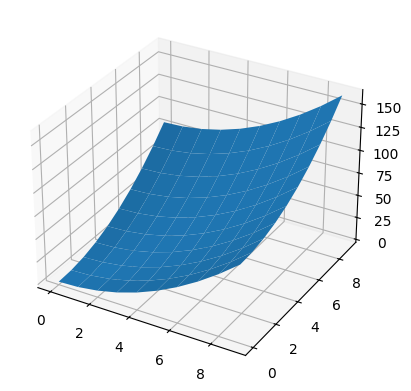

In [ ]:

from mpl_toolkits.mplot3d import Axes3D
import numpy as np
x, y = np.arange(0, 10,1), np.arange(0, 10, 1)
m, n = np.meshgrid(x, y)
# print(m,n)
import matplotlib.pyplot as plt
z = m**2 + n**2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(m, n, z)


plt.show()

In [ ]:
import torch
import torch.nn as nn
class SwinEmbedding(nn.Module):
    def __init__(self, patch_size = 16, emb_size = 96):
        super().__init__()
        self.patch_size = patch_size
        self.linear_embedding = nn.Conv2d(3, emb_size, patch_size, patch_size)
    
    def forward(self, x):
        B, C, H, W = x.shape
        x = self.linear_embedding(x)
        x = x.view(B,(H*W//self.patch_size**2), -1)
        return x

In [4]:
import torch
import torch.nn as nn
class SwinEmbedding(nn.Module):
    def __init__(self, patch_size = 4, emb_size = 96):
        super().__init__()
        self.patch_size = patch_size
        self.linear_embedding = nn.Conv2d(3, emb_size, patch_size, patch_size)
    
    def forward(self, x):
        B, C, H, W = x.shape
        x = self.linear_embedding(x)
        print(x.shape)
        x = x.view(B,(H*W//self.patch_size**2), -1)
        return x

In [5]:
img = torch.randn(1,3,224, 224)
cls = SwinEmbedding()
ok = cls.forward(img)

torch.Size([1, 96, 56, 56])


In [101]:
def window_partition(x, win):
    B, H, W, C = x.shape #(1,8,8,1)
    x = x.view(B, H//win, win, W//win, win, C)  #(1,2,4,2,4,1)
    # print(x)
    x = x.permute(0, 1,3,2,4,5)  # (1, 2, 2, 4, 4, 1)
    # print(x)
    x = x.reshape(-1, win, win, C ) #(4, 4, 4, 1)
    # print(x)
    return x


def create_mask(H, W, win, shift):
    img_mask = torch.zeros((1, H, W, 1), dtype=torch.float32)
    count = 0

    for h in (slice(0, -win), slice(-win, -shift), slice(-shift, None)):
        for w in (slice(0, -win), slice(-win, -shift), slice(-shift, None)):
            img_mask[:, h, w, :] = count
            count += 1
    # print(img_mask)
    mask = window_partition(img_mask, win)        # (num_windows, win, win, 1)
    mask = mask.view(-1, win * win)               # (num_windows, win*win)
    # print(mask.unsqueeze(1))
    # print(mask.unsqueeze(2))
    # print(mask)
    mask = mask.unsqueeze(1) - mask.unsqueeze(2)  # (num_windows, win*win, win*win)
    # print(mask)
    mask = mask.masked_fill(mask != 0, float('-inf'))
    mask = mask.masked_fill(mask == 0, 0.0)
    print(mask)
    return mask


m = create_mask(14,14,7,3)


tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., -inf, -inf, -inf],
         [0., 0., 0.,  ..., -inf, -inf, -inf],
         [0., 0., 0.,  ..., -inf, -inf, -inf],
         ...,
         [-inf, -inf, -inf,  ..., 0., 0., 0.],
         [-inf, -inf, -inf,  ..., 0., 0., 0.],
         [-inf, -inf, -inf,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., -inf, -inf, -inf],
         [0., 0., 0.,  ..., -inf, -inf, -inf],
         [0., 0., 0.,  ..., -inf, -inf, -inf],
         ...,
         [-inf, -inf, -inf,  ..., 0., 0., 0.],
         [-inf, -inf, -inf,  ..., 0., 0., 0.],
         [-inf, -inf, -inf,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., -inf, -inf, -inf],
         [0., 0., 0.,  ..., -inf, -inf, -inf],
         [0., 0., 0.,  ..., -inf, -inf, -inf],
 

In [102]:
m.shape

torch.Size([4, 49, 49])

In [27]:
import torch

torch.set_printoptions(threshold=float('inf'))
print(m.unsqueeze(1).unsqueeze(0))


tensor([[[[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
           [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],

In [30]:
m

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., -inf, 0., -inf],
         [-inf, 0., -inf, 0.],
         [0., -inf, 0., -inf],
         [-inf, 0., -inf, 0.]],

        [[0., 0., -inf, -inf],
         [0., 0., -inf, -inf],
         [-inf, -inf, 0., 0.],
         [-inf, -inf, 0., 0.]],

        [[0., -inf, -inf, -inf],
         [-inf, 0., -inf, -inf],
         [-inf, -inf, 0., -inf],
         [-inf, -inf, -inf, 0.]]])